## Import Libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
import tensorflow
from tensorflow import keras
from keras.models import load_model
from keras.layers import Dense,BatchNormalization, Dropout
from keras import Sequential
from keras.callbacks import EarlyStopping

## Load Dataset

In [40]:
df = pd.read_csv('ai4i2020.csv')

### First Five Rows

In [41]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Last Five Rows

In [42]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


### Check Null Values

In [43]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


### Info

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### Select Target and Features

In [45]:
X = df.drop(columns = ['Machine failure','UDI','Product ID','TWF','HDF','PWF','OSF','RNF'])
y = df['Machine failure']

In [46]:
X.shape, y.shape

((10000, 6), (10000,))

In [47]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## EDA

In [48]:
X['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


In [49]:
y.value_counts()

,count
Machine failure,
0,9661
1,339


In [50]:
X['Power'] = X['Torque [Nm]'] * X['Rotational speed [rpm]']
X['Temp_diff'] = X['Process temperature [K]'] - X['Air temperature [K]']
X['Torque_per_wear'] = X['Torque [Nm]'] / (X['Tool wear [min]'] + 1)

In [51]:
num_col = X.select_dtypes(include = np.number).columns
cat_col = X.select_dtypes(include = 'object').columns

In [52]:
num_col.shape, cat_col.shape

((8,), (1,))

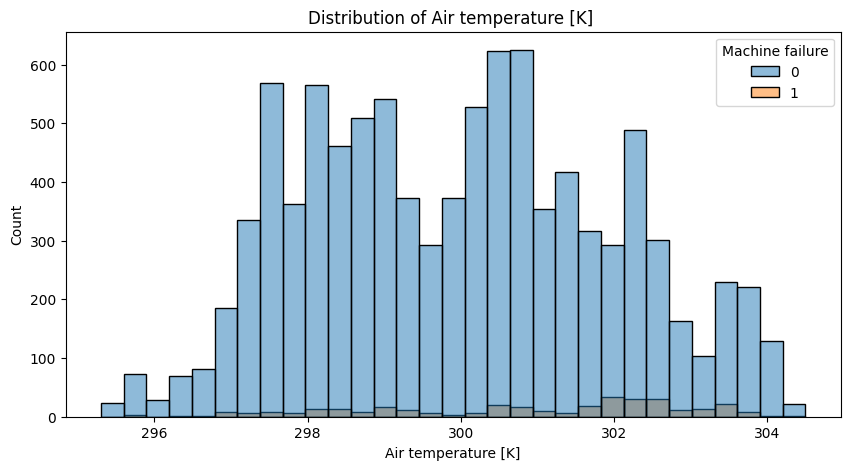

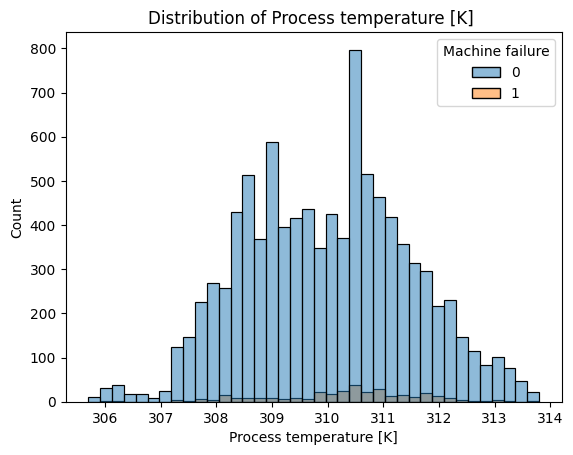

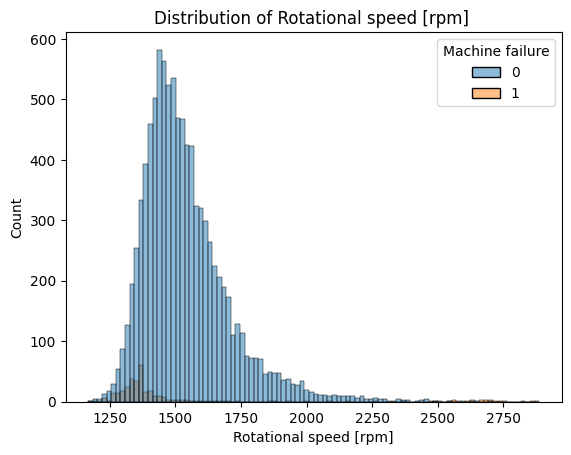

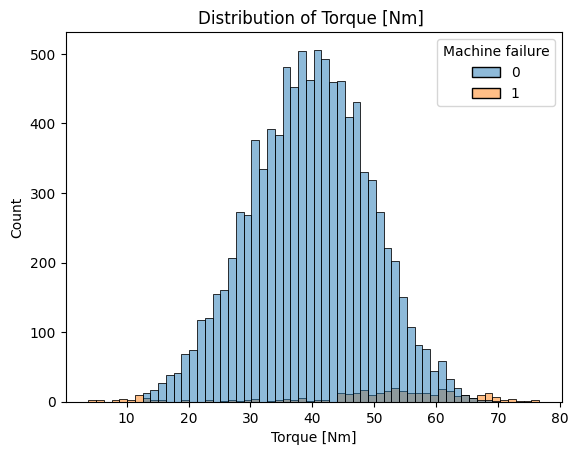

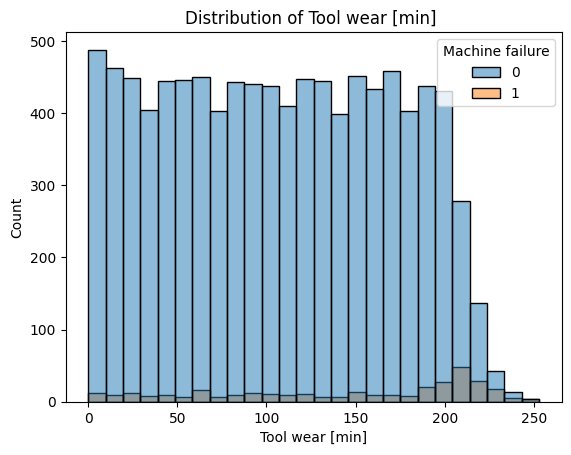

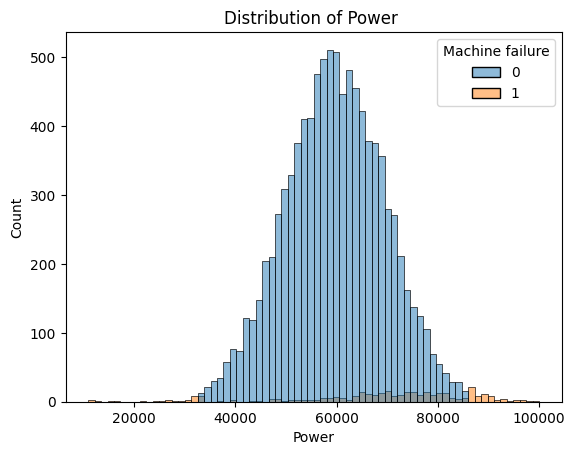

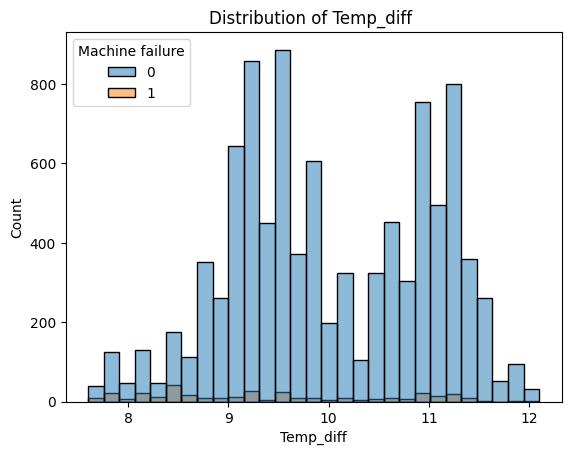

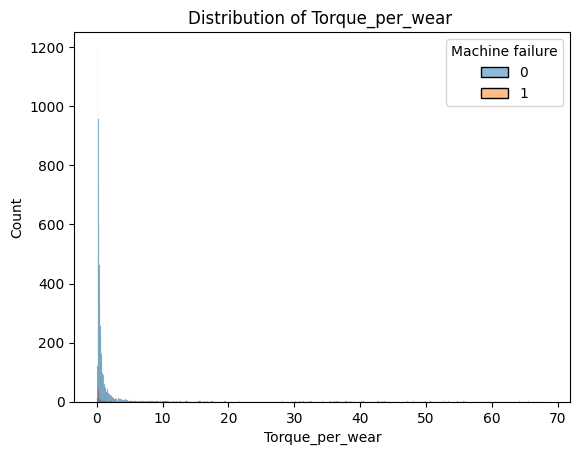

In [53]:
plt.figure(figsize = (10,5))
for i in num_col:
    sns.histplot(x = X[i], hue = y)
    plt.title(f'Distribution of {i} ')
    plt.show()


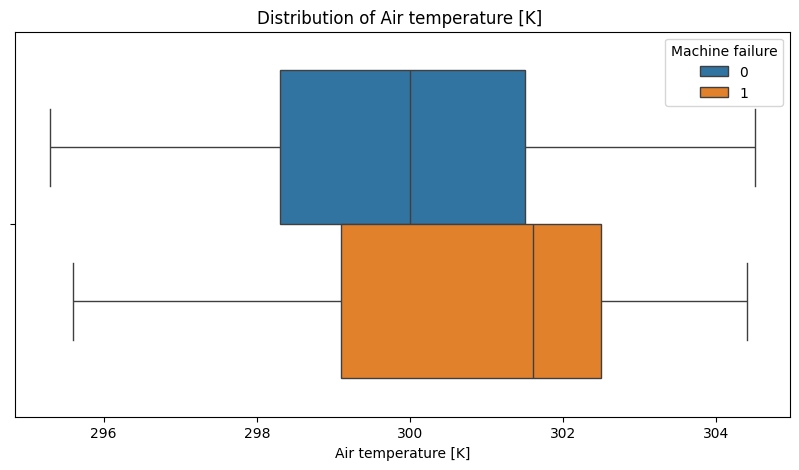

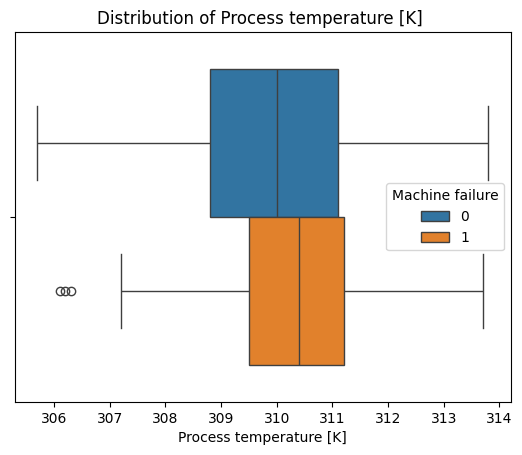

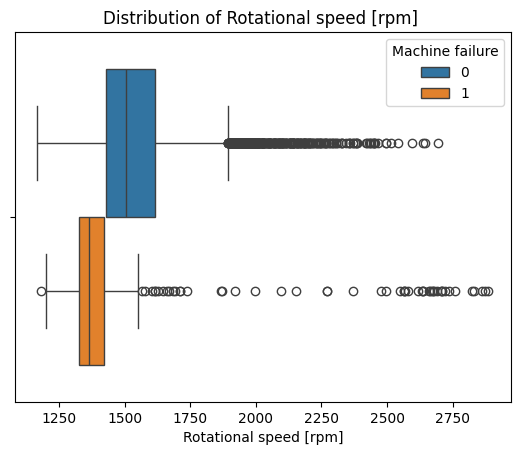

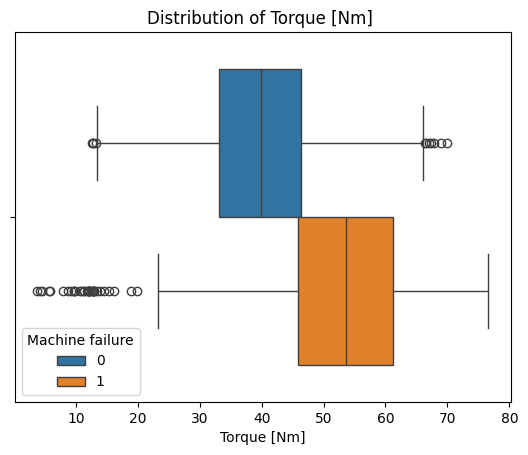

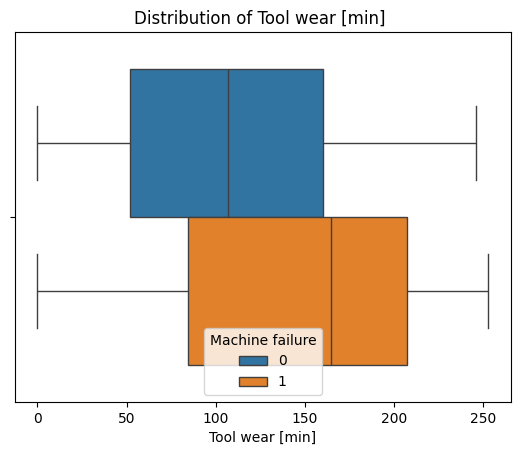

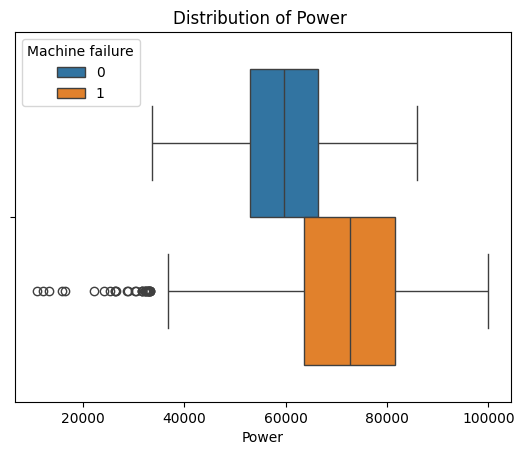

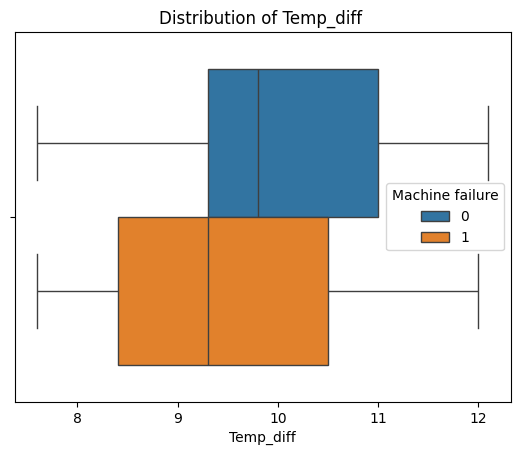

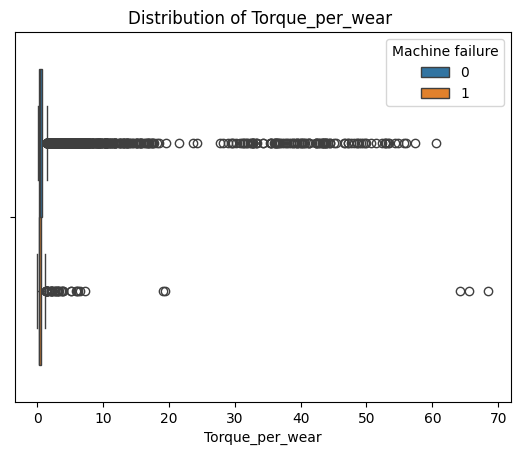

In [54]:
plt.figure(figsize = (10,5))
for i in num_col:
    sns.boxplot(x = X[i], hue = y)
    plt.title(f'Distribution of {i} ')
    plt.show()

### Separate Training, testing and validation Data

In [55]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.5,stratify=y_temp,random_state=42)

In [56]:
X_train.shape, X_temp.shape, X_val.shape, y_test.shape

((8000, 9), (2000, 9), (1000, 9), (1000,))

In [57]:
preprocessor = ColumnTransformer(transformers = [
    ('num', StandardScaler(), num_col),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
])

In [58]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power',
       'Temp_diff', 'Torque_per_wear'],
      dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Type'], dtype='object'))])

In [59]:
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [60]:
#smote = SMOTE(random_state=42)

#X_train_smote, y_train_smote = smote.fit_resample(X_train_processed,y_train)

#print("Before SMOTE:")
#print(y_train.value_counts())

#print("\nAfter SMOTE:")
#print(pd.Series(y_train_smote).value_counts())

In [61]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print(class_weight_dict)

{0: np.float64(0.51753137533963), 1: np.float64(14.760147601476016)}


### Make Model

In [62]:
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],),
                 kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [64]:
callback = EarlyStopping(monitor='val_auc',
    min_delta=0.0001,
    patience=10,
    verbose=1,
    mode='max',
    restore_best_weights=True,
    start_from_epoch=5)

In [65]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [66]:
history = model.fit(X_train_processed, y_train, epochs=100, batch_size=32, validation_data=(X_val_processed,y_val), callbacks=[callback])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7155 - auc: 0.6738 - loss: 0.6969 - val_accuracy: 0.9670 - val_auc: 0.8894 - val_loss: 0.3424
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9209 - auc: 0.7515 - loss: 0.3704 - val_accuracy: 0.9700 - val_auc: 0.9236 - val_loss: 0.2337
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9514 - auc: 0.7790 - loss: 0.2632 - val_accuracy: 0.9710 - val_auc: 0.9243 - val_loss: 0.1892
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9628 - auc: 0.8425 - loss: 0.2161 - val_accuracy: 0.9650 - val_auc: 0.9543 - val_loss: 0.1760
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9636 - auc: 0.8715 - loss: 0.1985 - val_accuracy: 0.9700 - val_auc: 0.9550 - val_loss: 0.1654
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9660 - auc: 0.8910 - loss: 0.1865 - val_accuracy: 0.9700 - val_auc: 0.9588 - val_loss: 0.1603
Epoch 7/100
250/250 ━━━━━━━━━━━━━

## Evaluate Model

In [67]:
loss, acc, auc = model.evaluate(X_val_processed, y_val)
print('Val Accuracy:', acc)
print('Val AUC:', auc)
print('Loss', loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9840 - auc: 0.9859 - loss: 0.0683
Val Accuracy: 0.984000027179718
Val AUC: 0.9859334826469421
Loss 0.06832339614629745


In [68]:
test_prob = model.predict(X_test_processed).ravel()

y_pred = (test_prob > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [69]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, test_prob)

# F1 score har threshold ke liye calculate karo
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

Best threshold: 0.522
At this threshold -> Precision: 0.811, Recall: 0.882, F1: 0.845


In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.988
Precision: 0.7894736842105263
Recall: 0.8823529411764706
F1: 0.8333333333333334

Confusion Matrix:
[[958   8]
 [  4  30]]


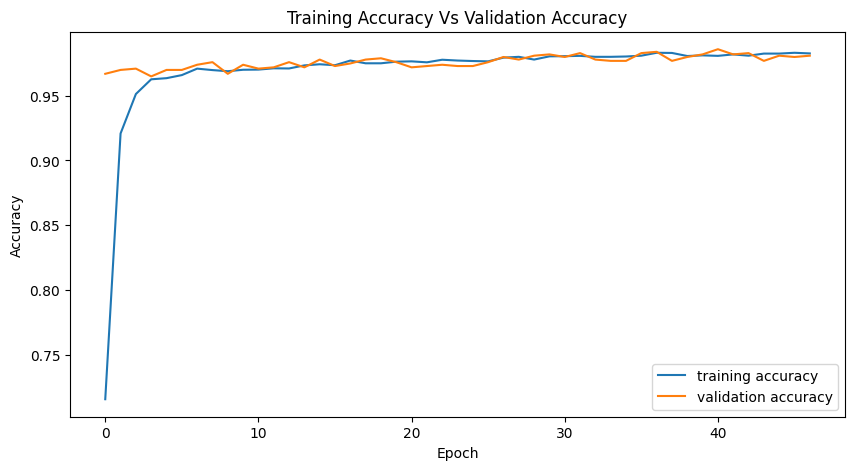

In [71]:
plt.figure(figsize = (10,5))
plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.title('Training Accuracy Vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

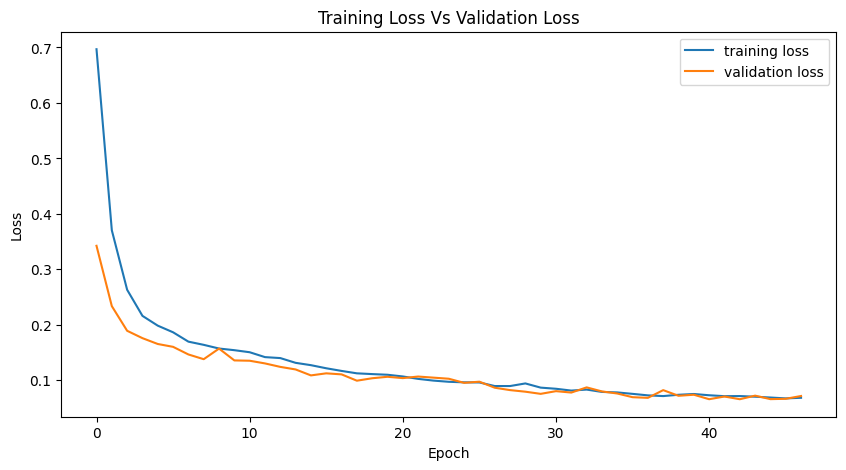

In [72]:
plt.figure(figsize = (10,5))
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.title('Training Loss Vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       966
           1       0.79      0.88      0.83        34

    accuracy                           0.99      1000
   macro avg       0.89      0.94      0.91      1000
weighted avg       0.99      0.99      0.99      1000



### Save model

In [74]:
model.save('model.keras')

In [75]:
joblib.dump(preprocessor, 'ColumnTransformer.pkl')
print('column Transformer save successfuly')

column Transformer save successfuly
